# Домашнее задание 2: Построение простого классификатора изображений

> :warning: **Note:** Отчет представлен в конце документа

## Цель:
Изучить применение методов машинного обучения для классификации изображений, сравнить эффективность классических алгоритмов и нейронных сетей.

## Задание:

### 1. Подготовка данных:
* Выберите набор данных:
    * MNIST для классификации рукописных цифр.
    * Или CIFAR-10 для классификации объектов в цветных изображениях.
* Разделите данные на обучающую (80%) и тестовую (20%) выборки.

In [ ]:
%pip install numpy matplotlib scikit-learn tensorflow-gpu seaborn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import cifar10

In [2]:
(x_train_original, y_train_original), (x_test_original, y_test_original) = cifar10.load_data()
print("x_train_original.shape =", x_train_original.shape, "y_train_original.shape =", y_train_original.shape)
print("x_test_original.shape =", x_test_original.shape, "y_test_original.shape =", y_test_original.shape)


# NOTE: original train/test share is 50/10, that is not 80/20 so resplit is needed
x_all_original = np.concatenate([x_train_original, x_test_original], axis=0)
y_all_original = np.concatenate([y_train_original, y_test_original], axis=0)

x_train, x_test, y_train, y_test = train_test_split(x_all_original, y_all_original, test_size=0.2, random_state=42)

print("x_train.shape =", x_train.shape, "y_train.shape =", y_train.shape)
print("x_test.shape =", x_test.shape, "y_test.shape =", y_test.shape)

x_train_original.shape = (50000, 32, 32, 3) y_train_original.shape = (50000, 1)
x_test_original.shape = (10000, 32, 32, 3) y_test_original.shape = (10000, 1)
x_train.shape = (48000, 32, 32, 3) y_train.shape = (48000, 1)
x_test.shape = (12000, 32, 32, 3) y_test.shape = (12000, 1)


In [3]:
# Normalize values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

CIFAR10 examples


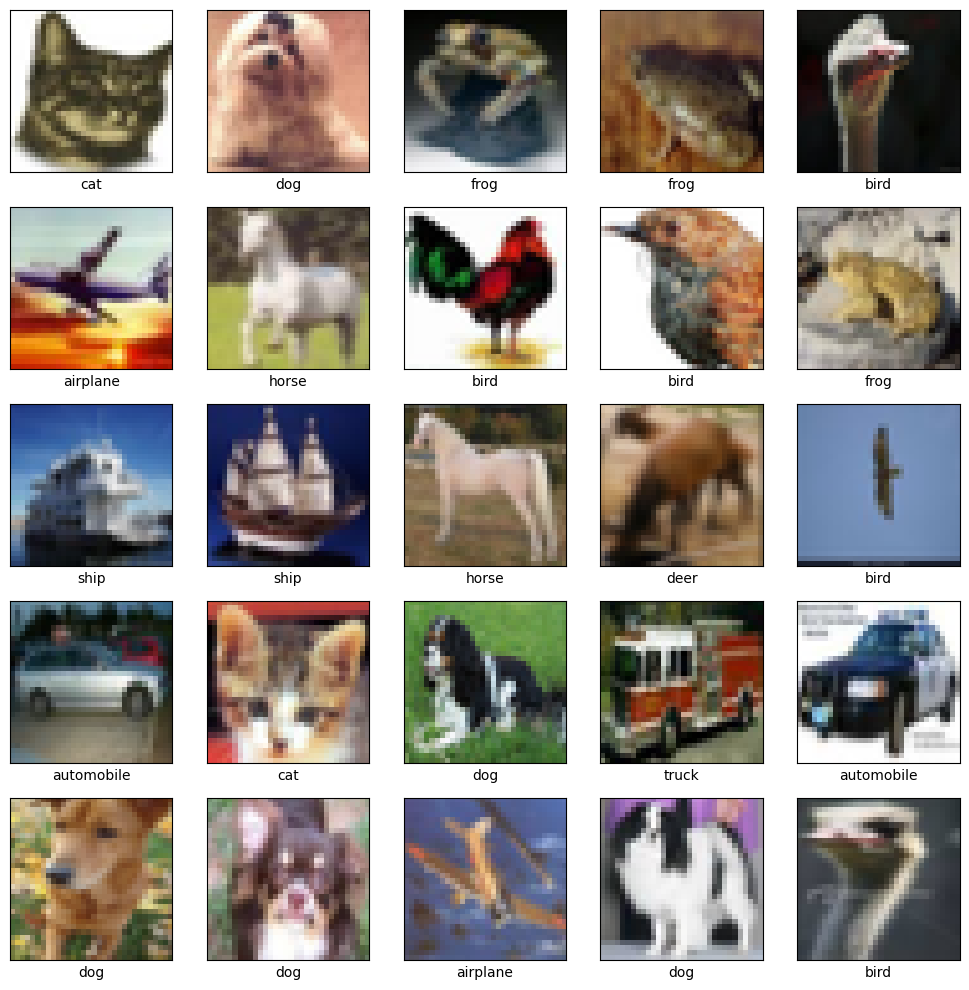

In [7]:
# Visualize
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print('CIFAR10 examples')
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.tight_layout()
plt.show()

### 2. Классификация с использованием kNN или SVM:
* Реализуйте классификатор k-ближайших соседей (kNN) или метод опорных векторов (SVM).
* Обучите модель на обучающей выборке.
* Предскажите классы на тестовой выборке.
* Вычислите метрики качества: точность, полнота, F1-score.
* Постройте матрицу ошибок (confusion matrix).

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import time

x_train_flat = x_train.reshape(x_train.shape[0], -1)
x_test_flat = x_test.reshape(x_test.shape[0], -1)

print(f"Num of features: {x_train_flat.shape[1]}")

print("Start training...")
start_time = time.time()
svm = SVC(kernel='rbf', C=5, verbose=True)
svm.fit(x_train_flat, y_train.ravel())
train_time = time.time() - start_time
print(f"Time spent: {train_time:.2f}s")


print("Start prediction...")
start_time = time.time()
y_pred = svm.predict(x_test_flat)
pred_time = time.time() - start_time
print(f"Time spent: {pred_time:.2f}s")


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

Num of features: 3072
Start training...
[LibSVM]...........*....*
optimization finished, #iter = 15883
obj = -4656.905596, rho = 1.296620
nSV = 4297, nBSV = 412
............*......*
optimization finished, #iter = 18604
obj = -8119.903218, rho = -0.694724
nSV = 4899, nBSV = 1184
..........*.....*
optimization finished, #iter = 15471
obj = -5280.565840, rho = -0.196327
nSV = 4164, nBSV = 617
...........*.....*
optimization finished, #iter = 16374
obj = -6557.434063, rho = -0.986656
nSV = 4237, nBSV = 892
........*.....*
optimization finished, #iter = 13033
obj = -3203.258126, rho = -1.119708
nSV = 3810, nBSV = 188
.......*....*
optimization finished, #iter = 11229
obj = -2899.901132, rho = -1.903197
nSV = 3225, nBSV = 188
.........*.....*
optimization finished, #iter = 14297
obj = -3416.237000, rho = -0.915631
nSV = 4127, nBSV = 196
...........*.....*
optimization finished, #iter = 16846
obj = -5080.564246, rho = -2.113258
nSV = 4469, nBSV = 469
..................*........*
optimization 

SVM Accuracy: 0.5637
SVM Precision: 0.5633
SVM Recall: 0.5637
SVM F1-score: 0.5629


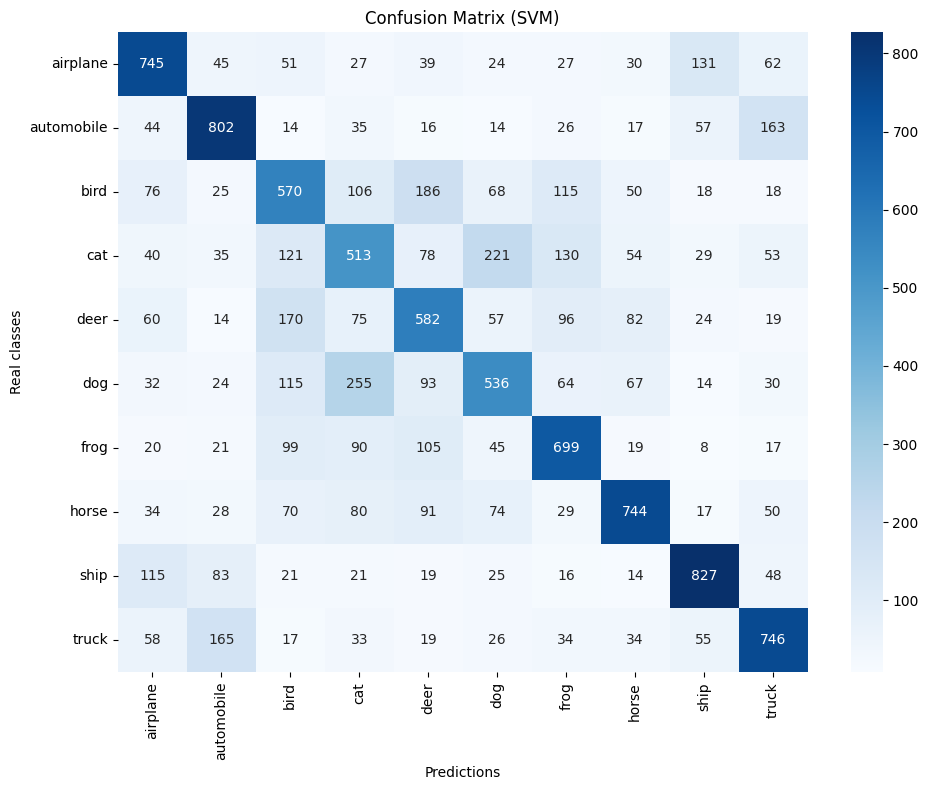

In [25]:
print(f"SVM Accuracy: {accuracy:.4f}")
print(f"SVM Precision: {precision:.4f}")
print(f"SVM Recall: {recall:.4f}")
print(f"SVM F1-score: {f1:.4f}")


cm = confusion_matrix(y_test.ravel(), y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predictions')
plt.ylabel('Real classes')
plt.title('Confusion Matrix (SVM)')
plt.tight_layout()
plt.show()

### 3. Построение и обучение нейронной сети:
* Создайте многослойный перцептрон (MLP) с использованием Keras или PyTorch.
* Определите архитектуру сети (количество слоев, нейронов, функции активации).
* Обучите модель на тех же данных.
* Проанализируйте динамику обучения (графики потерь и точности).

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

mlp = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(1024, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

mlp.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
mlp.summary()
history = mlp.fit(x_train, y_train_cat, epochs=100, batch_size=128, validation_split=0.1, callbacks=[])
test_loss, test_acc = mlp.evaluate(x_test, y_test_cat)
print(f"Accuracy: {test_acc:.4f}")

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_6 (Flatten)         (None, 3072)              0         
                                                                 
 dense_24 (Dense)            (None, 1024)              3146752   
                                                                 
 dropout_13 (Dropout)        (None, 1024)              0         
                                                                 
 dense_25 (Dense)            (None, 512)               524800    
                                                                 
 dropout_14 (Dropout)        (None, 512)               0         
                                                                 
 dense_26 (Dense)            (None, 256)               131328    
                                                                 
 dropout_15 (Dropout)        (None, 256)              

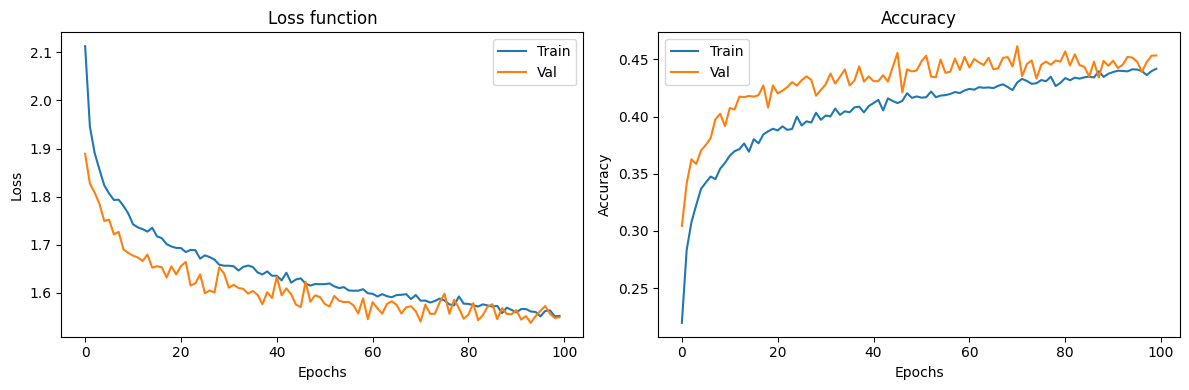

In [27]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss function')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

375/375 [==============================] - 1s 1ms/step
MLP Accuracy: 0.4588
MLP Precision: 0.4682
MLP Recall: 0.4588
MLP F1-score: 0.4566


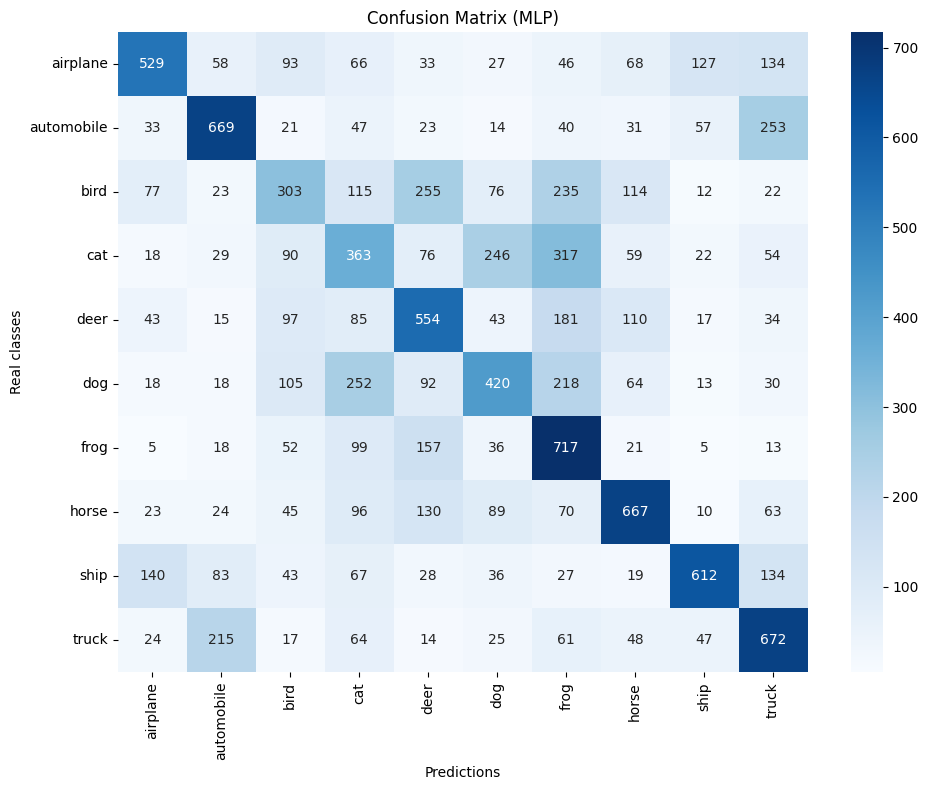

In [28]:

y_pred_mlp = mlp.predict(x_test)
y_pred_mlp_classes = np.argmax(y_pred_mlp, axis=1)

accuracy_mlp = accuracy_score(y_test, y_pred_mlp_classes)
precision_mlp = precision_score(y_test, y_pred_mlp_classes, average='weighted')
recall_mlp = recall_score(y_test, y_pred_mlp_classes, average='weighted')
f1_mlp = f1_score(y_test, y_pred_mlp_classes, average='weighted')

print(f"MLP Accuracy: {accuracy_mlp:.4f}")
print(f"MLP Precision: {precision_mlp:.4f}")
print(f"MLP Recall: {recall_mlp:.4f}")
print(f"MLP F1-score: {f1_mlp:.4f}")

cm_mlp = confusion_matrix(y_test.ravel(), y_pred_mlp_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predictions')
plt.ylabel('Real classes')
plt.title('Confusion Matrix (MLP)')
plt.tight_layout()
plt.show()

### 4. Сравнительный анализ моделей:
* Сравните результаты классического алгоритма (kNN/SVM) и нейронной сети.
* Обсудите преимущества и недостатки каждого подхода.
* Предложите способы улучшения моделей.

+-------+----------+-----------+----------+----------+
| Model | Accuracy | Precision |  Recall  |    F1    |
+-------+----------+-----------+----------+----------+
|  SVM  | 0.563667 |  0.563259 | 0.563667 | 0.562939 |
|  MLP  | 0.458833 |  0.468224 | 0.458833 | 0.456623 |
+-------+----------+-----------+----------+----------+


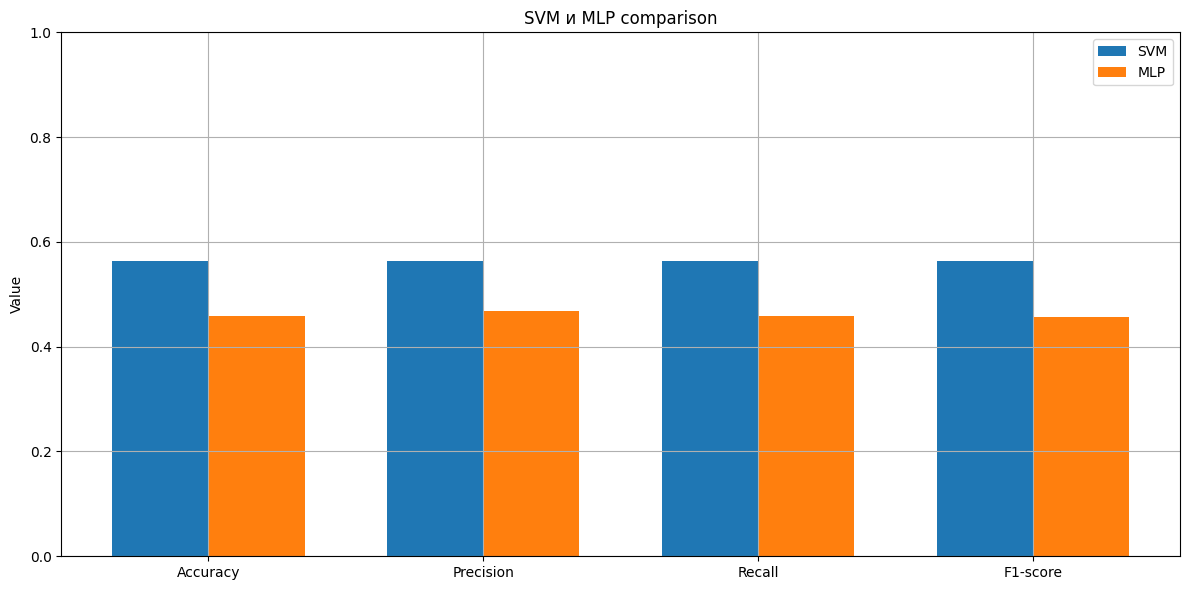

In [55]:
from prettytable import PrettyTable

results = [
    ['Model', 'Accuracy', 'Precision', 'Recall', 'F1'],
    ['SVM', accuracy, precision, recall, f1],
    ['MLP', accuracy_mlp, precision_mlp, recall_mlp, f1_mlp],
]
cmp_table = PrettyTable() 
cmp_table.field_names = results[0]
cmp_table.float_format = ".6"
cmp_table.add_row(results[1])
cmp_table.add_row(results[2])
print(cmp_table)

metrics = {
    'Model': ['SVM', 'MLP'],
    'Accuracy': [accuracy, accuracy_mlp],
    'Precision': [precision, precision_mlp],
    'Recall': [recall, recall_mlp],
    'F1-score': [f1, f1_mlp]
}

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, results[1][1:], width, label='SVM')
ax.bar(x + width/2, results[2][1:], width, label='MLP')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylim(0, 1)
ax.set_ylabel('Value')
ax.set_title('SVM и MLP comparison')
ax.legend()

plt.tight_layout()
ax.grid('on')
plt.show()


## Отчет

* Описание выбранных методов и настроек моделей.
* Результаты обучения и тестирования (метрики, графики, матрицы ошибок).
* Сравнительный анализ и выводы.

### Использованные методы

#### SVM - метод опорных векторов
- Ядро: радиальная базисная функция (RBF)
- Параметр регуляризации: C = 5

#### MLP - многослойный перцептрон
- Архитектура:
  - Входной слой: (3072 нейрона)
  - Скрытый слой 1: 1024 нейрона, ReLU, dropout 0.3
  - Скрытый слой 2: 512 нейронов, ReLU, dropout 0.4
  - Скрытый слой 3: 256 нейронов, ReLU, dropout 0.5
  - Выходной слой: 10 нейронов, softmax
- Обучен на 100 эпохах, оптимизатор Adam

### Результаты обучения и тестирования

<div align="center">

| Model | Accuracy | Precision |  Recall  |    F1    |
|-------|----------|-----------|----------|----------|
|  **SVM**  | 0.563667 |  0.563259 | 0.563667 | 0.562939 |
|  **MLP**  | 0.458833 |  0.468224 | 0.458833 | 0.456623 |

</div>
<br>
<div align="center">
  <img src=cm_svm.png width="600"/>
  <img src=cm_mlp.png width="600"/>
</div>

### Сравнительный анализ моделей

MLP проявил себя немного лучше чем SVM, но оба алгоритма показали достаточно скудные результаты на задаче классификации CIFAR-10. Это можно объяснить тем, что ни SVM, ни MLP не способны эффективно учитывать пространственную структуру изображений.

По матрице ошибок SVM, видно что классификатор имеет трудности с различением некоторых классов (например, кошек и собак).

Для MLP результаты еще хуже (путает лягушку и собаку). А на графиках лоссов и точности при обучения MLP видно, что модель достигает плато после определенного числа эпох, что свидетельствует о том, что у выбранной модели есть предел.

#### Плюсы и минусы каждого метода
| **SVM** | **MLP** |
|--|--|
| **+** Меньше параметров для настройки | **+** Лучше обучается сложным зависимостям |
| **+** Более устойчив к переобучению на маленьких выборках | **+** Легко модифицировать архитектуру |
| **-** Медленное обучение на больших данных | **-** Не учитывает пространственную структуру изображений |
| **-** Не учитывает структуру изображений | **-** Склонность к переобучению |

### Потенциальные улучшения


| **SVM** | **MLP** |
|--|--|
| Выделение признаков с помощью других алгоритмов перед SVM  | Усложнить архитектуру |
| Подобрать лучшие параметры (C, gamma) через GridSearch | Применить аугментацию данных |
| Применить уменьшение размерности (PCA) | Использовать другие подходы к регуляризации |

А вообще лучше использовать сверточные сети для подобных задач классификации...

## Вывод

Оба подхода показали ограниченные возможности при классификации изображений CIFAR-10. Это ожидаемо. Для серьезного улучшения результатов необходимо перейти к использованию других методов, которые специально были разработаны для cv задач. В относительном плане SVM чуть лучше классифицирует CIFAR-10 чем MLP, но MLP быстрее обучился.
